# Домашнє завдання: Прогнозування орендної плати за житло

## Мета завдання
Застосувати знання з лекції для побудови моделі лінійної регресії, що прогнозує орендну плату за житло в Індії. Ви пройдете весь цикл вирішення задачі машинного навчання: від дослідницького аналізу до оцінки якості моделі.

## Опис датасету
**House Rent Prediction Dataset** містить інформацію про 4700+ оголошень про оренду житла в Індії з такими параметрами:
- **BHK**: Кількість спалень, залів, кухонь
- **Rent**: Орендна плата (цільова змінна)
- **Size**: Площа в квадратних футах
- **Floor**: Поверх та загальна кількість поверхів
- **Area Type**: Тип розрахунку площі
- **Area Locality**: Район
- **City**: Місто
- **Furnishing Status**: Стан меблювання
- **Tenant Preferred**: Тип орендаря
- **Bathroom**: Кількість ванних кімнат
- **Point of Contact**: Контактна особа

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `House_Rent_Dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (включно з типами даних та кількістю значень)


In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Завантажуємо дані
df = pd.read_csv('../data/House_Rent_Dataset.csv')

print(f'Набір даних містить {df.shape[0]} рядків та {df.shape[1]} колонок')
print()
df.info()
df.head()

Набір даних містить 4746 рядків та 12 колонок

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Posted On          4746 non-null   str  
 1   BHK                4746 non-null   int64
 2   Rent               4746 non-null   int64
 3   Size               4746 non-null   int64
 4   Floor              4746 non-null   str  
 5   Area Type          4746 non-null   str  
 6   Area Locality      4746 non-null   str  
 7   City               4746 non-null   str  
 8   Furnishing Status  4746 non-null   str  
 9   Tenant Preferred   4746 non-null   str  
 10  Bathroom           4746 non-null   int64
 11  Point of Contact   4746 non-null   str  
dtypes: int64(4), str(8)
memory usage: 445.1 KB


,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


## Завдання 2: Дослідницький аналіз даних (EDA) (5 балів)

**Що потрібно зробити:**
1. **Аналіз пропущених значень.** Перевірте наявність і відсоток пропущених значень у кожній колонці
2. **Базова статистика.** Обчисліть базову статистику (середнє, квартилі, стандартне відхилення) для числових змінних.
3. **Аналіз цільової змінної.** Побудуйте гістограму розподілу цільової змінної (Rent)
4. **Робота з викидами.** Знайдіть та видаліть викиди в цільовій змінній (якщо є). Визначити викиди можна будь-яким зрозумілим для вас способом, як варіант - таким, що використовується в побудові box-plot (https://en.wikipedia.org/wiki/Box_plot#Example_with_outliers).
5. **Аналіз категоріальних змінних.** Виведіть кількість унікальних значень для кожної з категоріальних колонок.


In [3]:
# 1. Аналіз пропущених значень (хоча у info ми побачили, що немає пустих значень, усі рядки із значеннями).

missing_table = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': (df.isnull().sum() / len(df)) * 100
})

missing_table.round(2)

,missing_count,missing_percent
Posted On,0,0.0
BHK,0,0.0
Rent,0,0.0
Size,0,0.0
Floor,0,0.0
Area Type,0,0.0
Area Locality,0,0.0
City,0,0.0
Furnishing Status,0,0.0
Tenant Preferred,0,0.0


In [4]:
# 2. Базова статистика, опис числових змінних

stats = df[['BHK', 'Rent', 'Size', 'Bathroom']].describe()
stats.round(2)

,BHK,Rent,Size,Bathroom
count,4746.00,4746.00,4746.00,4746.00
mean,2.08,34993.45,967.49,1.97
std,0.83,78106.41,634.20,0.88
min,1.00,1200.00,10.00,1.00
25%,2.00,10000.00,550.00,1.00
50%,2.00,16000.00,850.00,2.00
75%,3.00,33000.00,1200.00,2.00
max,6.00,3500000.00,8000.00,10.00


**Висновки з базової статистики:**

- У датасеті немає пропущених значень.
- Медіанна орендна плата становить 16 000, тобто половина обʼєктів має оренду до 16 000.
- Середня орендна плата становить 34 993, що значно більше за медіану. Це може означати наявність дорогих обʼєктів, які сильно впливають на середнє.
- 75% обʼєктів мають орендну плату до 33 000.
- Максимальна орендна плата 3 500 000 виглядає як можливий викид, тому її потрібно додатково перевірити.
- Площа також має велике максимальне значення — 8000, тому для `Size` теж варто перевірити викиди (як максимальні, так і мінімальні).

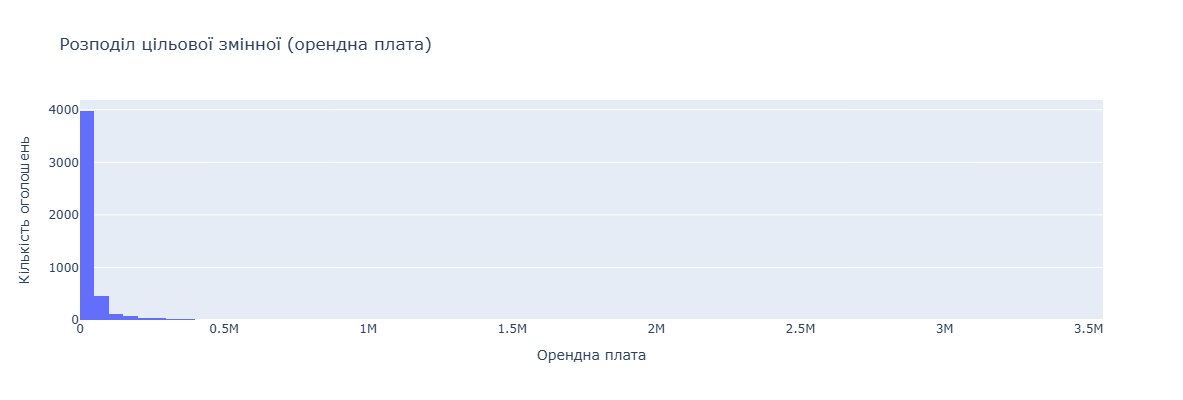

In [5]:
# 3. Аналіз цільової змінної - розподілу Rent

fig = px.histogram(
    df,
    x='Rent',
    nbins=100,
    title='Розподіл цільової змінної (орендна плата)',
    labels={'Rent': 'Орендна плата', 'count': 'Кількість оголошень'}
)
fig.update_layout(
    showlegend=False,
    height=400
)

fig.update_yaxes(title_text='Кількість оголошень')
fig.update_xaxes(title_text='Орендна плата')

fig.show()

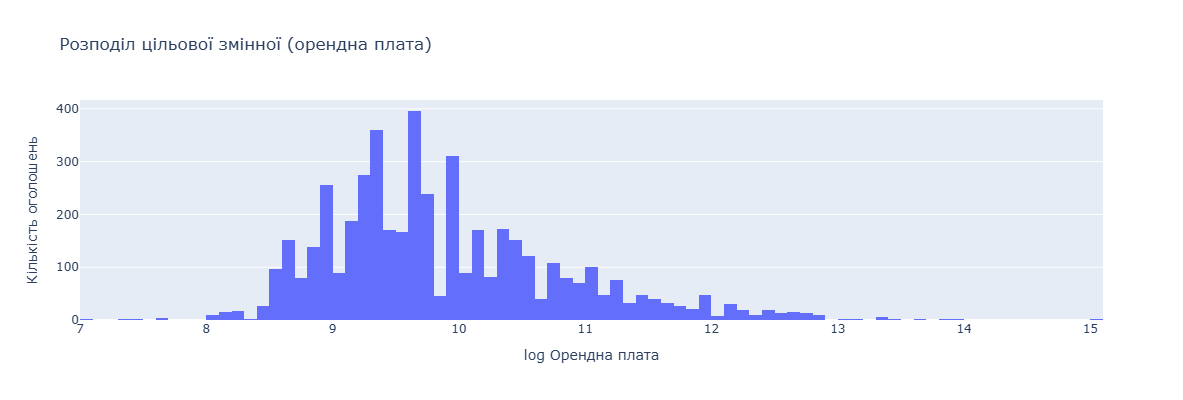

In [6]:
df['log_target'] = np.log1p(df['Rent'])
fig = px.histogram(
    df,
    x='log_target',
    nbins=100,
    title='Розподіл цільової змінної (орендна плата)',
    labels={'log_target': 'log Орендна плата', 'count': 'Кількість оголошень'}
)
fig.update_layout(
    showlegend=False,
    height=400
)

fig.update_yaxes(title_text='Кількість оголошень')
fig.update_xaxes(title_text='log Орендна плата')

fig.show()

**Висновок щодо розподілу цільової змінної `Rent`:**

Розподіл орендної плати є правосторонньо скошеним: більшість оголошень мають відносно невисоку орендну плату, але є кілька дуже дорогих обʼєктів.

Через великі значення `Rent` основна частина даних на звичайній гістограмі виглядає стиснутою біля початку графіка. Після логарифмування розподіл стає більш читабельним і ближчим до нормального. Більшість значень зосереджені зліва, а справа є довгий хвіст через дорогі обʼєкти.

Це означає, що в цільовій змінній є можливі викиди, які потрібно додатково перевірити на наступному етапі.

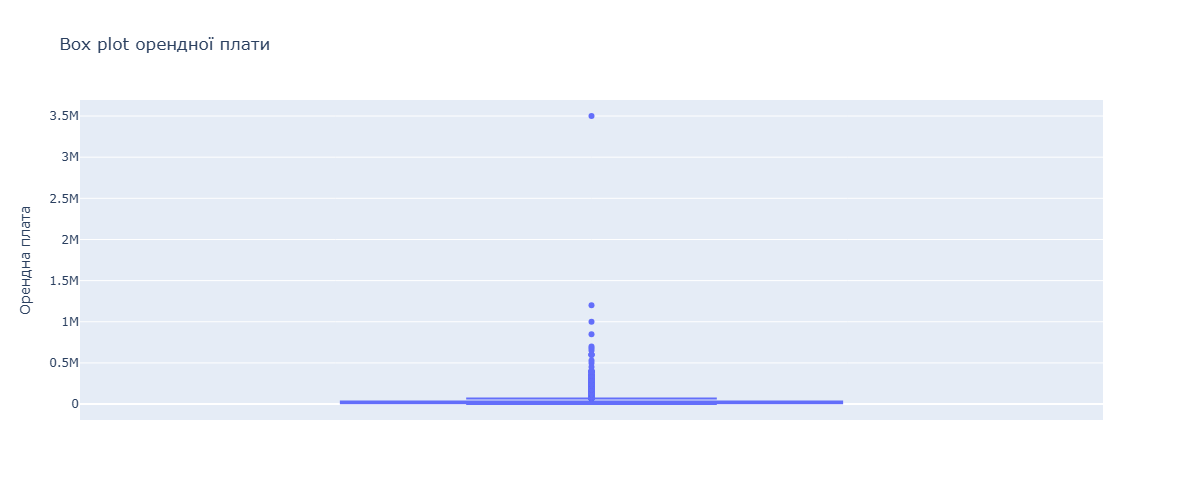

In [7]:
# 4. Робота з викидами у цільовій змінній Rent

# Box plot для Rent
fig = px.box(
    df,
    y='Rent',
    title='Box plot орендної плати',
    labels={'Rent': 'Орендна плата'}
)
fig.update_layout(height=500)
fig.show()

In [8]:
# Шукаємо викиди через IQR

Q1 = df['Rent'].quantile(0.25)
Q3 = df['Rent'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Q1: {Q1}')
print(f'Q3: {Q3}')
print(f'IQR: {IQR}')
print(f'Нижня межа: {lower_bound}')
print(f'Верхня межа: {upper_bound}')

Q1: 10000.0
Q3: 33000.0
IQR: 23000.0
Нижня межа: -24500.0
Верхня межа: 67500.0


In [9]:
# Дивимось кількість викидів

outliers = df[df['Rent'] > upper_bound]

print(f'Кількість викидів у Rent: {len(outliers)}')
print(f'Відсоток викидів: {round(len(outliers) / len(df) * 100, 2)}%')

outliers[['Rent', 'BHK', 'Size', 'City', 'Area Locality']].sort_values(by='Rent', ascending=False).head(10)

Кількість викидів у Rent: 520
Відсоток викидів: 10.96%


,Rent,BHK,Size,City,Area Locality
1837,3500000,3,2500,Bangalore,Marathahalli
1001,1200000,4,5000,Mumbai,Juhu
827,1000000,4,3064,Mumbai,"Raheja Artesia, Worli"
1329,850000,4,3200,Mumbai,Breach Candy
1459,700000,4,3200,Mumbai,"Lady Ratan Tower, Worli"
1484,680000,4,1962,Mumbai,Khar West
1319,650000,5,3000,Mumbai,Khar West
792,600000,5,3200,Mumbai,Bandra East
726,600000,4,2500,Mumbai,"Mount Marry, Bandra West"
1384,600000,5,4500,Mumbai,Bandra West


In [10]:
# Видаляємо викиди

df_clean = df[df['Rent'] <= upper_bound].copy()

print(f'Розмір датасету до видалення викидів: {df.shape}')
print(f'Розмір датасету після видалення викидів: {df_clean.shape}')

Розмір датасету до видалення викидів: (4746, 13)
Розмір датасету після видалення викидів: (4226, 13)


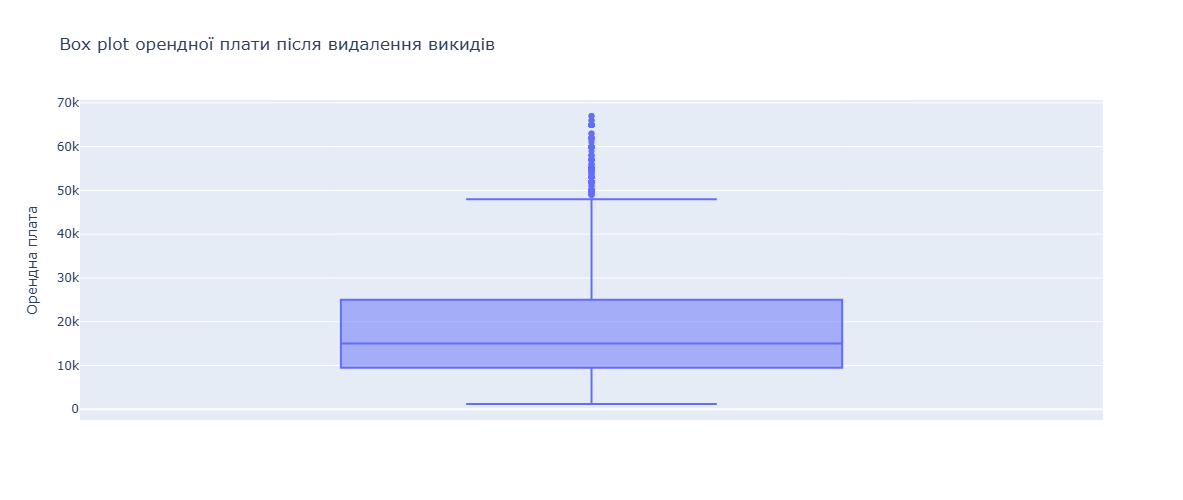

In [11]:
# Перевірка box plot після видалення

fig = px.box(
    df_clean,
    y='Rent',
    title='Box plot орендної плати після видалення викидів',
    labels={'Rent': 'Орендна плата'}
)

fig.update_layout(height=500)
fig.show()

**Висновок щодо викидів:**

Для пошуку викидів у цільовій змінній `Rent` було використано метод IQR.  
За цим методом верхня межа становить 67 500, тому всі значення орендної плати вище цієї межі були визначені як потенційні викиди.

Було знайдено 520 таких значень, що становить 10.96% від датасету. Це можуть бути реальні дорогі обʼєкти, але вони сильно впливають на розподіл `Rent` і можуть погіршити якість лінійної регресії.

Тому для подальшого аналізу було створено очищений датасет `df_clean`, у якому залишилися обʼєкти з орендною платою до 67 500.

In [12]:
# 5. Аналіз категоріальних змінних

object_cols = df_clean.select_dtypes(include=['object', 'string']).columns
unique_counts = df_clean[object_cols].nunique()

print('Кількість унікальних значень у категоріальних колонках:')
print(unique_counts)

Кількість унікальних значень у категоріальних колонках:
Posted On              80
Floor                 340
Area Type               3
Area Locality        1997
City                    6
Furnishing Status       3
Tenant Preferred        3
Point of Contact        3
dtype: int64


**Висновок щодо категоріальних змінних:**

У більшості категоріальних колонок кількість унікальних значень невелика: `Area Type`, `City`, `Furnishing Status`, `Tenant Preferred`, `Point of Contact`.  
Колонки `Area Locality` і `Floor` мають багато унікальних значень, тому перед побудовою моделі їх потрібно буде обробити обережно. Posted On — це фактично дата, тому потім її перетворимо на дату.


## Завдання 3: Аналіз кореляцій та взаємозв'язків (3 бали)

**Що потрібно зробити:**
1. Обчисліть матрицю кореляцій для числових змінних
2. Візуалізуйте кореляційну матрицю за допомогою heatmap
3. Побудуйте scatter plot між Size та Rent
4. Проаналізуйте взаємозв'язок між BHK та Rent за допомогою boxplot (який розподіл плати для різних значень BHK)


In [13]:
# 1. Матриця кореляцій для числових змінних

# Створюємо датафрейм тільки з числовими метриками
metrics_df = df_clean[['BHK', 'Rent', 'Size', 'Bathroom']].dropna()

# Матриця кореляцій
correlation_matrix = metrics_df.corr()                                           

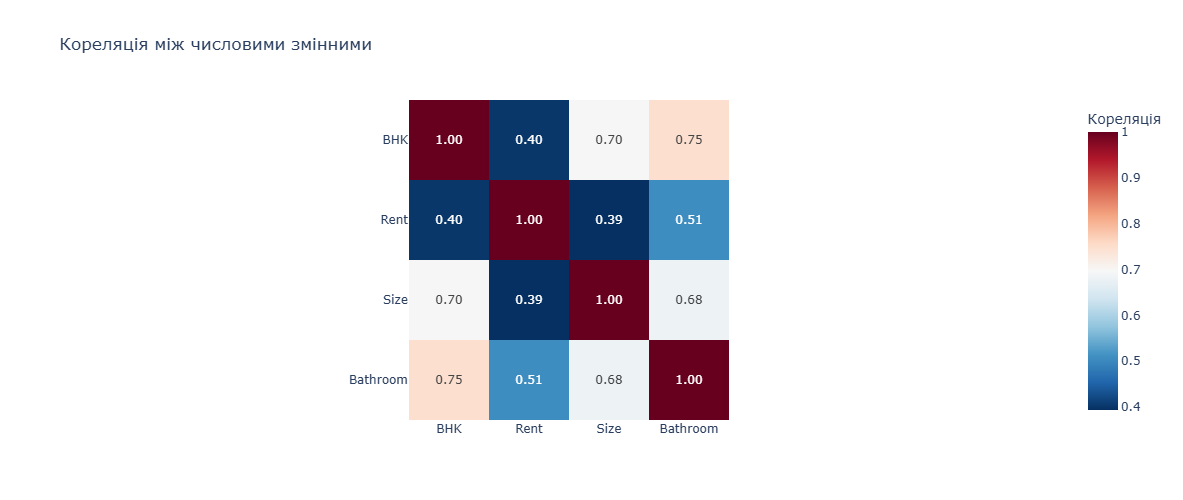

In [14]:
# 2. Візуалізація кореляційної матриці

fig = px.imshow(                                                                 
    correlation_matrix,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    title='Кореляція між числовими змінними',
    labels=dict(color="Кореляція")
)
fig.update_layout(height=500)
fig.show()

**Інтерпретація кореляції**
- **0.7-1.0** — сильна позитивна кореляція
- **0.3-0.7** — помірна позитивна кореляція
- **-0.3-0.3** — слабка або відсутня кореляція
- **-0.7--0.3** — помірна негативна кореляція
- **-1.0--0.7** — сильна негативна кореляція

**Висновок щодо кореляцій:**

Найбільший звʼязок із цільовою змінною `Rent` має кількість ванних кімнат `Bathroom` — кореляція 0.51. Це помірна позитивна кореляція: зі збільшенням кількості ванних кімнат орендна плата зазвичай зростає.

Також `Rent` має помірний позитивний звʼязок із кількістю кімнат `BHK` — 0.40 та площею `Size` — 0.39. Це означає, що більші квартири та квартири з більшою кількістю кімнат у середньому мають вищу орендну плату.

Між самими ознаками також є сильніші звʼязки: `BHK` і `Bathroom` мають кореляцію 0.75, `BHK` і `Size` — 0.70. Це логічно, бо більші квартири часто мають більше кімнат і ванних кімнат.

Загалом числові змінні мають позитивний звʼязок з орендною платою, але кореляції не дуже сильні. Тому для прогнозування `Rent` важливо буде враховувати не лише числові, а й категоріальні ознаки, наприклад місто, район, тип меблювання та тип площі.

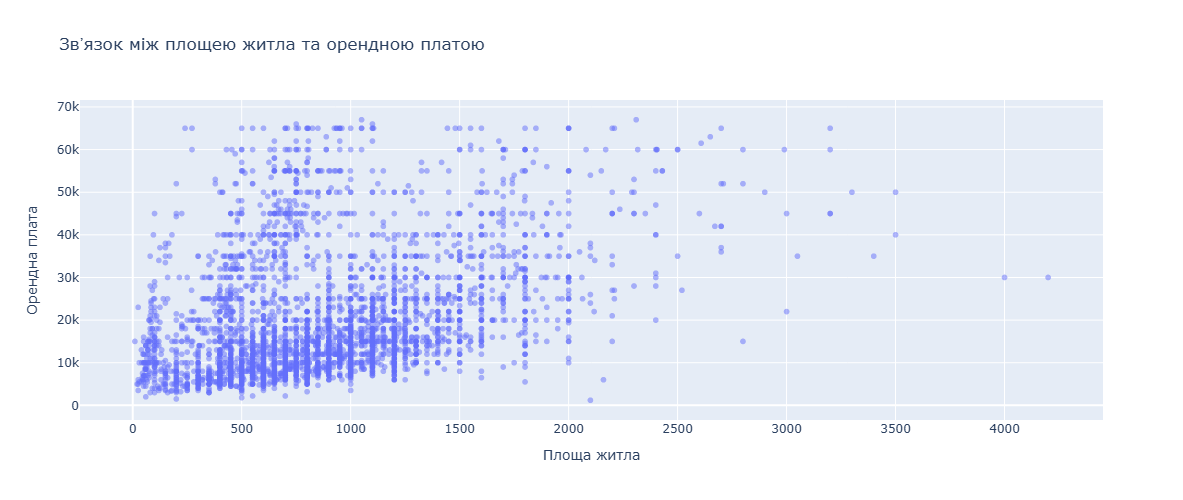

In [15]:
# 3. Scatter plot між Size та Rent

fig = px.scatter(
    df_clean,
    x='Size',
    y='Rent',
    title='Звʼязок між площею житла та орендною платою',
    labels={
        'Size': 'Площа житла',
        'Rent': 'Орендна плата'
    },
    opacity=0.5,
    hover_data=['City', 'BHK', 'Bathroom']
)

fig.update_layout(height=500)
fig.show()

**Висновок щодо звʼязку `Size` та `Rent`:**

На scatter plot видно загальну позитивну тенденцію: зі збільшенням площі житла орендна плата зазвичай зростає.  
Проте точки досить розсіяні, тому звʼязок між `Size` і `Rent` не є дуже сильним. Це підтверджує кореляція 0.39.

Отже, площа впливає на орендну плату, але не пояснює її повністю. На ціну також можуть впливати місто, район, меблювання, кількість кімнат та інші характеристики.

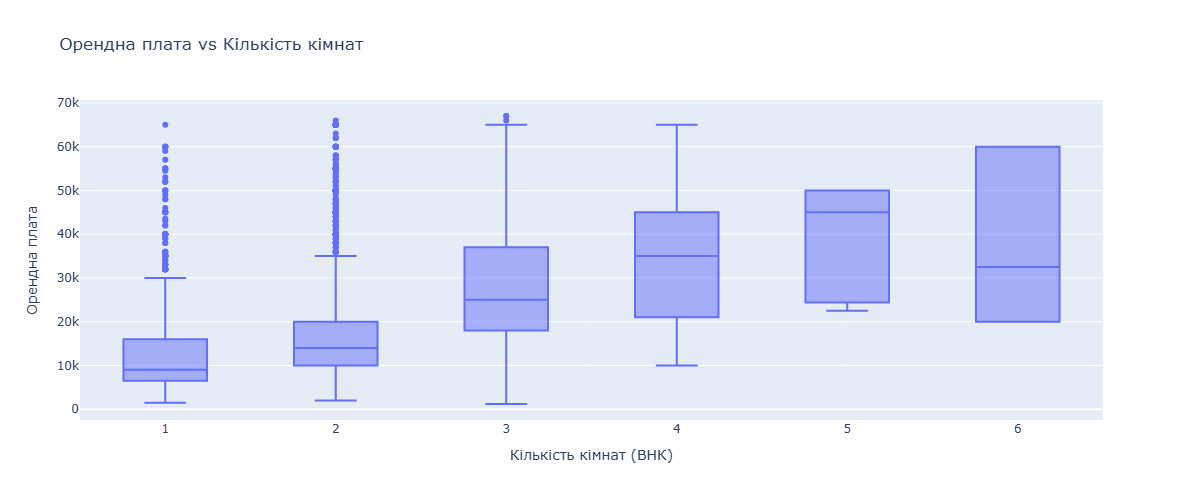

In [16]:
# 4. Взаємозв'язок між BHK та Rent за допомогою boxplot

fig = px.box(
    df_clean,
    x='BHK',
    y='Rent',
    title='Орендна плата vs Кількість кімнат',
    labels={'BHK': 'Кількість кімнат (ВНК)','Rent': 'Орендна плата'}
)

fig.update_layout(height=500)
fig.show()

**Висновок щодо звʼязку `BHK` та `Rent`:**

На boxplot видно, що зі збільшенням кількості кімнат `BHK` орендна плата загалом зростає.  
Для квартир з 1–2 BHK орендна плата нижча, а для 3–5 BHK медіана та діапазон значень вищі.

Також у групах 1 і 2 BHK є багато окремих високих значень, що можуть бути повʼязані з дорогими районами або кращими характеристиками житла.

Отже, `BHK` має позитивний звʼязок із `Rent`, але ціна залежить не лише від кількості кімнат, а й від інших факторів.

## Завдання 4: Feature Engineering та підготовка даних (4 бали)

**Що потрібно зробити:**
1. Закодуйте категоріальні змінні за допомогою One-Hot Encoding. Пригадайте, що в лекції ми говорили щодо кодування кат. змінних з великої кількістю різних значень і як працювати з такими випадками. Ви можете закодувати не всі кат. змінні, а лише ті, що вважаєте за потрібні (скажімо ті, що мають відносно небагато різних значень).
2. **Опціонально (по 0.5 бала за кожну доцільну ознаку):** Додайте нові ознаки, обчислені на основі наявних даних, які б на ваш погляд були корисними для моделі
3. Виберіть ознаки для побудови моделі (виключіть непотрібні колонки). Виключити можна, наприклад, ті колонки, які мають категоріальний тип і забагато (більше 20) різних значень. Треба виключити хоча б 1 колонку.
4. Розділіть дані на ознаки (X) та цільову змінну (y)
5. Застосуйте стандартизацію до числових ознак


In [17]:
# 1. Створюємо копію очищеного датасету для моделі

df_model = df_clean.copy()
df_model.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,log_target
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,9.210440
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,9.903538
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,9.741027
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,9.210440
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner,8.922792


In [18]:
# Перевіряємо кількість унікальних значень

df_model.select_dtypes(include=['object', 'string']).nunique().sort_values(ascending=False)

Area Locality        1997
Floor                 340
Posted On              80
City                    6
Area Type               3
Furnishing Status       3
Tenant Preferred        3
Point of Contact        3
dtype: int64

In [19]:
# Закодовуємо тільки ці колонки:
categorical_cols = [
    'Area Type',
    'City',
    'Furnishing Status',
    'Tenant Preferred',
    'Point of Contact'
]

In [20]:
# 2. Feature Engineering

df_model['Size_per_BHK'] = df_model['Size'] / df_model['BHK']
df_model['Bathroom_per_BHK'] = df_model['Bathroom'] / df_model['BHK']

df_model['Posted On'] = pd.to_datetime(df_model['Posted On'])
df_model['Posted_Month'] = df_model['Posted On'].dt.month

In [21]:
# 3. Вибираємо колонки для моделі

numeric_cols = [
    'BHK',
    'Size',
    'Bathroom',
    'Size_per_BHK',
    'Bathroom_per_BHK',
    'Posted_Month'
]

categorical_cols = [
    'Area Type',
    'City',
    'Furnishing Status',
    'Tenant Preferred',
    'Point of Contact'
]

In [22]:
# One-Hot Encoding

df_encoded = pd.get_dummies(
    df_model[numeric_cols + categorical_cols],
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

df_encoded.head()

,BHK,Size,Bathroom,Size_per_BHK,Bathroom_per_BHK,Posted_Month,Area Type_Carpet Area,Area Type_Super Area,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,Furnishing Status_Semi-Furnished,Furnishing Status_Unfurnished,Tenant Preferred_Bachelors/Family,Tenant Preferred_Family,Point of Contact_Contact Builder,Point of Contact_Contact Owner
0,2,1100,2,550.0,1.0,5,0,1,0,0,0,1,0,0,1,1,0,0,1
1,2,800,1,400.0,0.5,5,0,1,0,0,0,1,0,1,0,1,0,0,1
2,2,1000,1,500.0,0.5,5,0,1,0,0,0,1,0,1,0,1,0,0,1
3,2,800,1,400.0,0.5,7,0,1,0,0,0,1,0,0,1,1,0,0,1
4,2,850,1,425.0,0.5,5,1,0,0,0,0,1,0,0,1,0,0,0,1


In [23]:
# 4. Розділяємо на ознаки (X) та цільову змінну (y)

X = df_encoded                   # Ознаки
y = df_model['Rent']             # Цільова змінна

print(f"\nРозмір X (ознак): {X.shape}")
print(f"Розмір y (цілі): {y.shape}")


Розмір X (ознак): (4226, 19)
Розмір y (цілі): (4226,)


In [24]:
# 5. Стандартизація до числових ознак

scaler = StandardScaler()

X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

X.head()

,BHK,Size,Bathroom,Size_per_BHK,Bathroom_per_BHK,Posted_Month,Area Type_Carpet Area,Area Type_Super Area,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,Furnishing Status_Semi-Furnished,Furnishing Status_Unfurnished,Tenant Preferred_Bachelors/Family,Tenant Preferred_Family,Point of Contact_Contact Builder,Point of Contact_Contact Owner
0,0.052966,0.469859,0.272578,0.604132,0.147328,-0.861071,0,1,0,0,0,1,0,0,1,1,0,0,1
1,0.052966,-0.147778,-1.133910,-0.268747,-1.637671,-0.861071,0,1,0,0,0,1,0,1,0,1,0,0,1
2,0.052966,0.263980,-1.133910,0.313173,-1.637671,-0.861071,0,1,0,0,0,1,0,1,0,1,0,0,1
3,0.052966,-0.147778,-1.133910,-0.268747,-1.637671,1.546396,0,1,0,0,0,1,0,0,1,1,0,0,1
4,0.052966,-0.044839,-1.133910,-0.123267,-1.637671,-0.861071,1,0,0,0,0,1,0,0,1,0,0,0,1


**Висновок:**

Для підготовки даних було створено копію очищеного датасету `df_clean`.  
Категоріальні змінні з невеликою кількістю унікальних значень були закодовані за допомогою One-Hot Encoding.  
Колонки `Area Locality` і `Floor` не використовувалися напряму, оскільки мають багато унікальних значень.

Також було створено нові ознаки: `Size_per_BHK`, `Bathroom_per_BHK` та `Posted_Month`.  
Після цього дані були розділені на ознаки `X` та цільову змінну `y`, а числові ознаки були стандартизовані.

## Завдання 5: Розділення даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на навчальну (80%) та тестову (20%) вибірки.
2. Створіть модель лінійної регресії.
3. Навчіть модель на навчальних даних.
4. Виведіть усі коефіцієнти моделі (ваги) та напишіть, які 2 ознаки найбільше впливають на прогноз.
5. Зробіть прогнози на тренувальній та тестовій вибірках.

In [25]:
# 1. Розділяємо дані: 80% на навчання, 20% на тест

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,                                    # 20% даних йде на тест
    random_state=42                                   # фіксуємо випадковість для відтворюваності
)

# 2. Створюємо модель
model = LinearRegression()

# 3. Навчаємо модель на навчальних даних
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
# 4. Виводимо коефіцієнти моделі

coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_
})

coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values(by='abs_coefficient', ascending=False)

coef_df['coefficient'] = coef_df['coefficient'].round(2)
coef_df['abs_coefficient'] = coef_df['abs_coefficient'].round(2)

coef_df.head(10)

,feature,coefficient,abs_coefficient
12,City_Mumbai,19210.40,19210.40
18,Point of Contact_Contact Owner,-8597.11,8597.11
17,Point of Contact_Contact Builder,-5644.63,5644.63
14,Furnishing Status_Unfurnished,-4595.11,4595.11
2,Bathroom,4262.12,4262.12
13,Furnishing Status_Semi-Furnished,-3431.68,3431.68
1,Size,3103.92,3103.92
11,City_Kolkata,-2999.52,2999.52
7,Area Type_Super Area,-2485.38,2485.38
10,City_Hyderabad,-2432.73,2432.73


**Висновок щодо коефіцієнтів моделі:**

Найбільший позитивний вплив на прогноз має ознака `City_Mumbai`. Це означає, що житло в Mumbai в середньому має вищу орендну плату порівняно з базовим містом, яке було прибране під час One-Hot Encoding.

Також помітний вплив мають ознаки, повʼязані з контактною особою (`Point of Contact`) та меблюванням (`Furnishing Status`).  

Серед числових ознак найбільший вплив мають `Bathroom`, `Size` та `BHK`, що логічно: більші квартири з більшою кількістю кімнат і ванних кімнат зазвичай мають вищу орендну плату.

In [27]:
# 5. Прогнози на тренувальній та тестовій вибірках.

y_train_pred = model.predict(X_train)                   # Прогнози на навчальній вибірці
y_test_pred = model.predict(X_test)                     # Прогнози на тестовій вибірці (нові дані!)

# Порівняння перших 10 прогнозів з реальністю
comparison = pd.DataFrame({
    'Реальна ціна': y_test.values[:10],
    'Прогноз': y_test_pred[:10].round(0).astype(int),
    'Помилка': (y_test.values[:10] - y_test_pred[:10]).round(0).astype(int)
})

print("Приклади прогнозів на тестовій вибірці:")
comparison

Приклади прогнозів на тестовій вибірці:


,Реальна ціна,Прогноз,Помилка
0,22000,27580,-5580
1,5000,3253,1747
2,37000,40243,-3243
3,8000,2725,5275
4,15000,15324,-324
5,20000,23256,-3256
6,8500,17716,-9216
7,7000,4289,2711
8,3000,47,2953
9,8000,6283,1717


## Завдання 6: Оцінка якості моделі (2 бали)

**Що потрібно зробити:**
1. Обчисліть MAE, RMSE та R² для навчальної та тестової вибірок
2. Порівняйте метрики та зробіть висновок про якість моделі
3. Проаналізуйте і дайте висновок, чи є ознаки перенавчання або недонавчання (**Нагадування**: перенавчання - коли модель дуже добре працює на тренувальних даних, але погано на тестових; недонавчання - коли модель погано працює навіть на тренувальних даних)
4. Побудуйте графік розсіювання "реальні vs прогнозовані значення" та зробіть висновок про якість моделі


In [28]:
# 1. MAE, RMSE та R² для навчальної та тестової вибірок

# Метрики для тренувальної вибірки
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

# Метрики для тестової вибірки
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)

metrics_df = pd.DataFrame({
    'Вибірка': ['Train', 'Test'],
    'MAE': [mae_train, mae_test],
    'RMSE': [rmse_train, rmse_test],
    'R2': [r2_train, r2_test]
})

metrics_df.round(3)

,Вибірка,MAE,RMSE,R2
0,Train,5536.997,7657.984,0.693
1,Test,5540.000,7718.781,0.689


**Висновок щодо якості моделі:**

Модель показує схожі результати на тренувальній і тестовій вибірках.  
MAE на тестових даних становить приблизно 5540, тобто в середньому прогноз орендної плати помиляється приблизно на 5.5 тис.

RMSE становить приблизно 7719, що більше за MAE. Це означає, що в даних є окремі прогнози з більшими помилками.

R² на тестовій вибірці дорівнює приблизно 0.689. Це означає, що модель пояснює близько 69% змін у цільовій змінній `Rent`.

Оскільки метрики на train і test дуже близькі, явних ознак перенавчання немає. Модель працює стабільно, але не ідеально, тому якість можна покращувати за рахунок додаткових ознак або інших моделей.

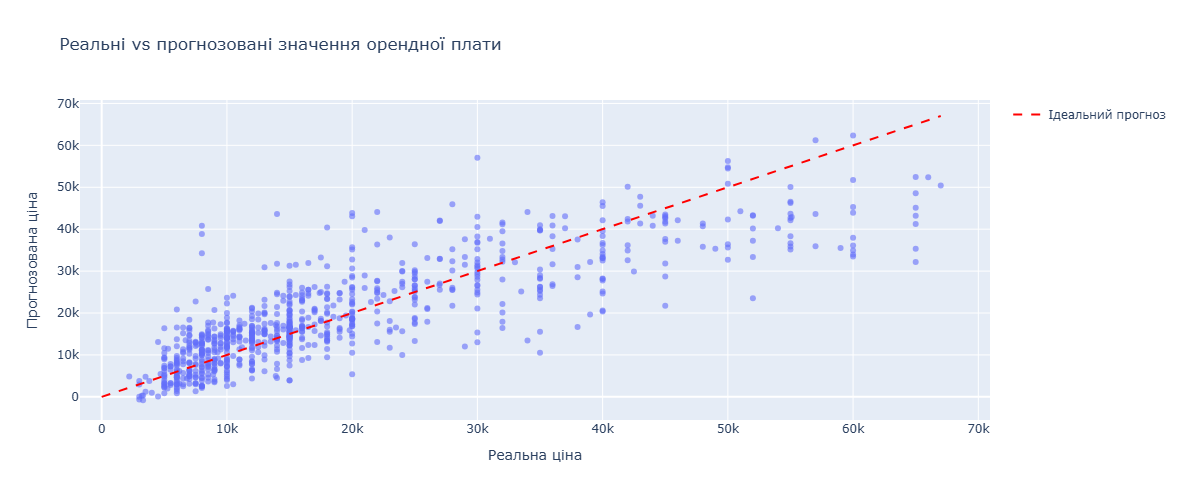

In [29]:
# 4. Графік реальних та прогнозованих значень

pred_df = pd.DataFrame({
    'Реальна ціна': y_test,
    'Прогнозована ціна': y_test_pred
})

fig = px.scatter(
    pred_df,
    x='Реальна ціна',
    y='Прогнозована ціна',
    title='Реальні vs прогнозовані значення орендної плати',
    opacity=0.6
)

# Додаємо ідеальну лінію, де прогноз = реальність
max_val = max(pred_df['Реальна ціна'].max(), pred_df['Прогнозована ціна'].max())

fig.add_trace(
    go.Scatter(
        x=[0, max_val],
        y=[0, max_val],
        mode='lines',
        name='Ідеальний прогноз',
        line=dict(color='red', dash='dash')
    )
)

fig.update_layout(height=500)
fig.show()

**Висновок щодо графіка:**

На графіку видно, що частина точок розташована близько до діагональної лінії, тобто модель для цих обʼєктів прогнозує орендну плату досить точно.

Водночас є точки, які помітно відхиляються від лінії. Це означає, що для частини обʼєктів модель помиляється сильніше.

Загалом модель вловлює основну залежність у даних, але має простір для покращення.

## Завдання 7: Аналіз помилок (4 бали)

**Що потрібно зробити:**
1. Обчисліть помилки (residuals = реальні - прогнозовані значення)
2. Побудуйте гістограму розподілу помилок
3. Створіть scatter plot помилок відносно величини прогнозованих значень. Чи росте помилка з ростом прогнозованого значення?
4. Знайдіть 5 прогнозів з найбільшими помилками
5. Проаналізуйте, на яких типах житла модель помиляється найбільше. Типи можна розрізняти за кількістю кімнат чи містом, наприклад.
6. Подумайте і напишіть, які наступні кроки ви б зробили, аби поліпшити якість моделі. Опціонально можна їх зробити і ми перевіримо :)

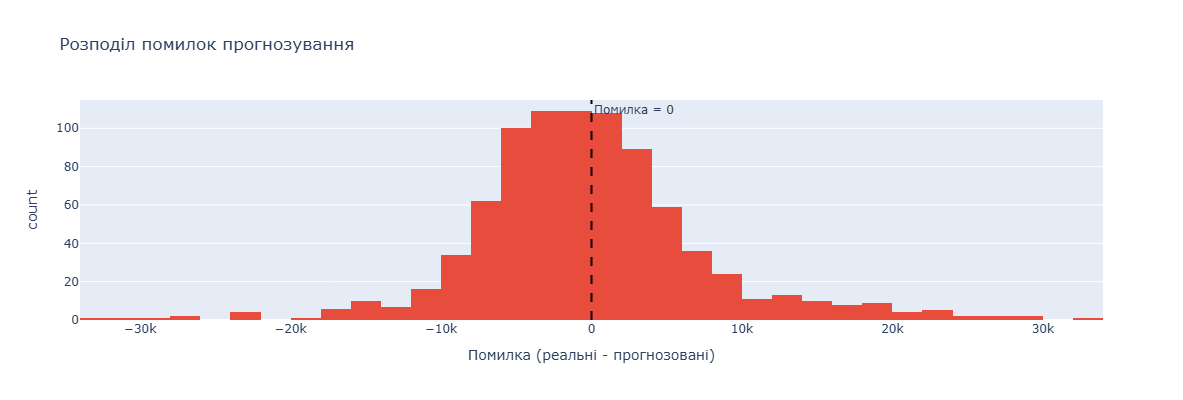

In [30]:
# 1. Розраховуємо помилки (залишки)
residuals = y_test - y_test_pred

# 2. Гістограма помилок
fig = px.histogram(
    x=residuals,
    nbins=50,
    title='Розподіл помилок прогнозування',
    labels={'x': 'Помилка (реальні - прогнозовані)', 'count': 'Кількість'},
    color_discrete_sequence=['#e74c3c']
)
fig.add_vline(x=0, line_dash="dash", line_color="black", annotation_text="Помилка = 0")
fig.update_layout(height=400)
fig.show()

**Висновок щодо розподілу помилок:**

Більшість помилок зосереджені біля 0, тобто для значної частини обʼєктів модель прогнозує орендну плату досить близько до реальних значень.

Розподіл помилок має хвости в обидві сторони. Це означає, що є випадки, коли модель як завищує прогноз, так і занижує його.

Додатна помилка означає, що реальна ціна була вища за прогнозовану, тобто модель занизила прогноз. Відʼємна помилка означає, що модель завищила прогноз.

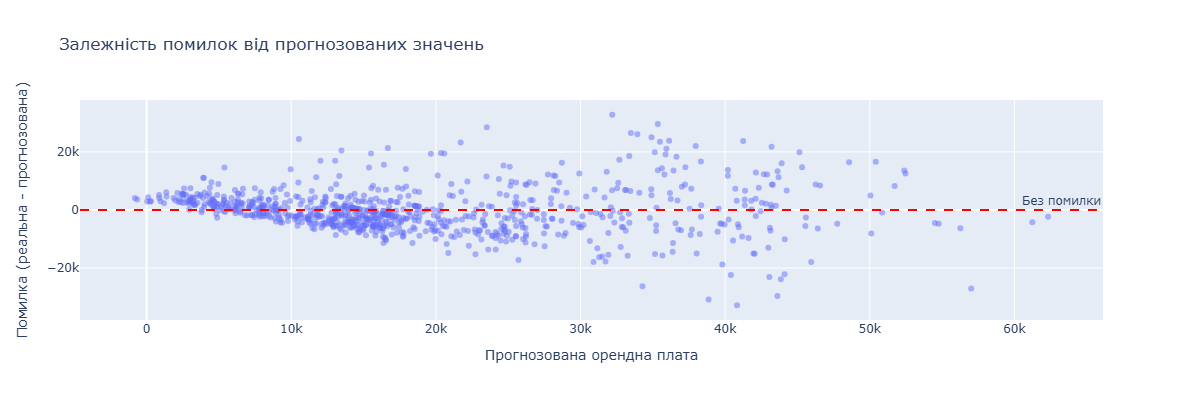

In [31]:
# 3. Scatter plot: помилки vs прогнозовані значення
fig = px.scatter(
    x=y_test_pred,
    y=residuals,
    title='Залежність помилок від прогнозованих значень',
    labels={
        'x': 'Прогнозована орендна плата',
        'y': 'Помилка (реальна - прогнозована)'
    },
    opacity=0.5
)

# Додаємо горизонтальну лінію на 0
fig.add_hline(y=0, line_dash="dash", line_color="red", annotation_text="Без помилки")

fig.update_layout(height=400)
fig.show()

**Висновок щодо залежності помилок від прогнозованих значень:**

На графіку видно, що для нижчих прогнозованих значень помилки переважно менші й розташовані ближче до нуля.

Для вищих прогнозованих значень розкид помилок стає більшим. Це означає, що модель гірше прогнозує дорожчі обʼєкти оренди.

Отже, модель краще працює для типових обʼєктів із нижчою або середньою орендною платою, але має більші помилки для дорожчого житла.

In [32]:
# 4. Топ-5 прогнозів з найбільшими помилками

error_df = df_model.loc[y_test.index, [
    'Rent', 'BHK', 'Size', 'Bathroom', 'City',
    'Area Type', 'Furnishing Status', 'Tenant Preferred', 'Point of Contact'
]].copy()

error_df['Predicted_Rent'] = y_test_pred.round(0).astype(int)
error_df['Residual'] = (error_df['Rent'] - error_df['Predicted_Rent']).astype(int)
error_df['Abs_Error'] = error_df['Residual'].abs()

top_errors = error_df.sort_values(by='Abs_Error', ascending=False).head(5)

top_errors

,Rent,BHK,Size,Bathroom,City,Area Type,Furnishing Status,Tenant Preferred,Point of Contact,Predicted_Rent,Residual,Abs_Error
549,8000,2,650,2,Mumbai,Carpet Area,Semi-Furnished,Family,Contact Agent,40822,-32822,32822
3962,65000,3,1850,3,Hyderabad,Carpet Area,Furnished,Bachelors,Contact Owner,32195,32805,32805
904,8000,2,550,2,Mumbai,Carpet Area,Unfurnished,Family,Contact Agent,38855,-30855,30855
3520,65000,3,1444,3,Chennai,Super Area,Semi-Furnished,Bachelors,Contact Agent,35345,29655,29655
598,14000,2,570,2,Mumbai,Carpet Area,Furnished,Family,Contact Agent,43611,-29611,29611


In [33]:
# 5. На яких типах житла модель помиляється найбільше

# Аналіз помилок за містом

city_errors = error_df.groupby('City')['Abs_Error'].agg(['count', 'mean', 'median'])
city_errors.sort_values(by='mean', ascending=False).round(0)

,count,mean,median
City,,,
Mumbai,118,9058.0,6831.0
Delhi,115,7234.0,5429.0
Hyderabad,165,5202.0,4524.0
Chennai,143,4733.0,3710.0
Kolkata,131,4178.0,2811.0
Bangalore,174,4044.0,2673.0


In [34]:
# Аналіз помилок за кількістю BHK

bhk_errors = error_df.groupby('BHK')['Abs_Error'].agg(['count', 'mean', 'median'])
bhk_errors.sort_values(by='mean', ascending=False).round(0)

,count,mean,median
BHK,,,
4,17,11579.0,8703.0
3,152,7800.0,6149.0
5,1,6266.0,6266.0
6,2,5306.0,5306.0
2,450,5076.0,3903.0
1,224,4478.0,3264.0


**Висновок по групах:**

За містами найбільша середня помилка спостерігається для Mumbai та Delhi. Це може означати, що для цих міст ціни більш різноманітні, і моделі складніше точно прогнозувати орендну плату.

За кількістю BHK найбільша середня помилка спостерігається для 4 BHK. Для 5 та 6 BHK кількість прикладів дуже мала, тому ці результати потрібно інтерпретувати обережно.

**Загальний висновок щодо аналізу помилок:**

Аналіз залишків показав, що більшість помилок моделі зосереджені біля нуля, тобто модель у багатьох випадках прогнозує орендну плату досить близько до реальних значень.

Водночас є окремі обʼєкти з великими помилками. На scatter plot видно, що зі збільшенням прогнозованої орендної плати розкид помилок також зростає. Це означає, що модель менш точно працює для дорожчих обʼєктів.

Найбільші помилки варто додатково перевірити за містом, кількістю кімнат, площею та типом меблювання. Ймовірно, на якість прогнозу впливають важливі фактори, які не повністю враховані в моделі, наприклад район (`Area Locality`) або поверх (`Floor`).

Для покращення моделі можна додатково обробити ознаки `Floor` та `Area Locality`, протестувати інші моделі та спробувати прогнозувати не сам `Rent`, а логарифмовану цільову змінну `log_target`.

__________________________________________________________________________________________________________________________________________________________
**Time spent — 5 год**

**What I learned**

- Базово познайомилась із темою машинного навчання та логікою побудови ML-рішення.
- Пройшла основні етапи роботи над задачею прогнозування:
  1. Розуміння бізнес-задачі.
  2. Збір та дослідження даних (EDA).
  3. Підготовка даних і Feature Engineering.
  4. Розділення даних на навчальну та тестову вибірки.
  5. Вибір моделі та її навчання на прикладі лінійної регресії.
  6. Оцінка якості моделі за допомогою MAE, RMSE та R².
  7. Аналіз помилок і пошук можливих шляхів покращення моделі.

- Навчилась будувати просту модель лінійної регресії для прогнозування орендної плати.
- Попрактикувалась у підготовці ознак: One-Hot Encoding, створення нових змінних, стандартизація числових ознак.
- Розібралась, як порівнювати якість моделі на train/test вибірках і перевіряти, чи є ознаки перенавчання.
- Зрозуміла базову логіку аналізу помилок: residuals, гістограма помилок, scatter plot та пошук найбільших відхилень.

Через обмежений час повністю глибоко засвоїти цей модуль поки складно, але основну суть і послідовність побудови ML-рішення зрозуміла. Для кращого закріплення теми потрібно буде ще додатково попрактикуватися на інших прикладах.